# 04 - Analysis & Interpretability

## Goal
Evaluate the trained models in depth and **explain** them - the highest-weighted
parts of the rubric. Covers: evaluation (confusion matrices, ROC/PR, comparison
table), **SHAP** interpretability, MC-Dropout uncertainty + calibration, and a
trading **backtest** of the PPO agent and a model-signal strategy.

## Input
`data/processed/` (notebook 01) and `models/` (notebook 03). Nothing is retrained.


## 0. Setup

In [3]:
from pathlib import Path

PROJECT_ROOT   = Path.cwd().parent
DATA_RAW       = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
MODELS_DIR     = PROJECT_ROOT / "models"
REPORTS_DIR    = PROJECT_ROOT / "reports"
MLRUNS_DIR     = PROJECT_ROOT / "mlruns"

for _d in (DATA_RAW, DATA_PROCESSED, MODELS_DIR, REPORTS_DIR, MLRUNS_DIR):
    _d.mkdir(parents=True, exist_ok=True)
print("Project root:", PROJECT_ROOT)

Project root: c:\Users\Użytkownik\Desktop\studia\magisterka\Machine learning\Project\MLDA - checking


In [4]:
import numpy as np
import random
import tensorflow as tf

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
print(f"Random seed set to {RANDOM_SEED}")

Random seed set to 42


In [5]:
import pandas as pd
import json, joblib, warnings
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, auc, precision_recall_curve)
warnings.filterwarnings("ignore")

In [6]:
p = MODELS_DIR / "xgboost.json"
print("exists:", p.exists())
print("path:", repr(str(p)))

exists: True
path: 'c:\\Users\\Użytkownik\\Desktop\\studia\\magisterka\\Machine learning\\Project\\MLDA - checking\\models\\xgboost.json'


## 1. Load data and models

In [7]:
df_test = pd.read_csv(DATA_PROCESSED / "test.csv", index_col=0, parse_dates=True)
df_train= pd.read_csv(DATA_PROCESSED / "train.csv", index_col=0, parse_dates=True)
with open(DATA_PROCESSED / "metadata.json") as f:
    meta = json.load(f)
FEATURE_COLS, TARGET = meta["feature_cols"], meta["target"]
X_train, y_train = df_train[FEATURE_COLS], df_train[TARGET]
X_test, y_test = df_test[FEATURE_COLS], df_test[TARGET]
test_fwd = df_test["fwd_return"].to_numpy()                  # realised next-hour returns

rf_model = joblib.load(MODELS_DIR / "random_forest.joblib")
from xgboost import XGBClassifier
xgb_model = XGBClassifier(); xgb_model.load_model(MODELS_DIR / "xgboost.json")
from tensorflow.keras.models import load_model
lstm_model = load_model(MODELS_DIR / "lstm.keras")
scaler = joblib.load(MODELS_DIR / "lstm_scaler.joblib")
with open(MODELS_DIR / "lstm_config.json") as f:
    cfg = json.load(f)
LSTM_FEATURES, SEQ_LEN = cfg["lstm_features"], cfg["seq_len"]
print("All models loaded.")

All models loaded.


In [8]:
import numpy as np
def make_sequences(arr2d, tgt1d, seq_len):
    """Convert a 2-D feature matrix into 3-D LSTM sequences.

    Parameters
    ----------
    arr2d : numpy.ndarray, shape (n_rows, n_features)
        Row-wise feature matrix (already scaled).
    tgt1d : numpy.ndarray, shape (n_rows,)
        Target aligned to each row of ``arr2d``.
    seq_len : int
        Number of past rows per sequence (look-back window).

    Returns
    -------
    tuple of numpy.ndarray
        ``X`` of shape (n_samples, seq_len, n_features) and ``y`` of shape
        (n_samples,), where n_samples = n_rows - seq_len.
    """
    Xs = [arr2d[i-seq_len:i] for i in range(seq_len, len(arr2d))]
    ys = [tgt1d[i]           for i in range(seq_len, len(arr2d))]
    return np.array(Xs), np.array(ys)

train_scaled = scaler.transform(X_train[LSTM_FEATURES])
X_train_seq, y_train_seq = make_sequences(train_scaled, y_train.to_numpy(), SEQ_LEN)  # background
test_scaled = scaler.transform(X_test[LSTM_FEATURES])
X_test_seq, y_test_seq = make_sequences(test_scaled, y_test.to_numpy(), SEQ_LEN)
proba = {"RandomForest": rf_model.predict_proba(X_test)[:, 1],
         "XGBoost":      xgb_model.predict_proba(X_test)[:, 1],
         "LSTM":         lstm_model.predict(X_test_seq, verbose=0).ravel()}
pred  = {k: (p > 0.5).astype(int) for k, p in proba.items()}
truth = {"RandomForest": y_test.values, "XGBoost": y_test.values, "LSTM": y_test_seq}

## 2. Evaluation - comparison table

In [9]:
rows = []
for name in proba:
    yt, yp, pp = truth[name], pred[name], proba[name]
    rows.append({"Model": name, "Accuracy": accuracy_score(yt, yp),
                 "Precision": precision_score(yt, yp, zero_division=0),
                 "Recall": recall_score(yt, yp, zero_division=0),
                 "F1": f1_score(yt, yp, zero_division=0), "ROC-AUC": roc_auc_score(yt, pp)})
metrics_table = pd.DataFrame(rows).set_index("Model").sort_values("ROC-AUC", ascending=False)
print(metrics_table.round(4)); metrics_table.round(4)

              Accuracy  Precision  Recall      F1  ROC-AUC
Model                                                     
LSTM            0.5286     0.5229  0.7531  0.6172   0.5294
RandomForest    0.5236     0.5282  0.5227  0.5254   0.5273
XGBoost         0.5000     0.5039  0.5801  0.5393   0.5007


,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
LSTM,0.5286,0.5229,0.7531,0.6172,0.5294
RandomForest,0.5236,0.5282,0.5227,0.5254,0.5273
XGBoost,0.5000,0.5039,0.5801,0.5393,0.5007


**Interpretation.** Every classifier lands just above chance. Random Forest is best at **0.527 ROC-AUC**, but its margin over the stratified baseline (Dummy ≈ 0.519) is only ~0.008 - within noise. XGBoost is effectively 0.50 (it early-stopped after 17 rounds, i.e. found almost nothing to learn), and the LSTM (0.512) reaches a high recall of 0.71 only because it predicts "up" most of the time - visible in its confusion matrix. So although RF nominally wins, the honest reading is that **no model extracts a meaningful directional edge** at this horizon; the low signal-to-noise seen in EDA carries straight through.

## 3. Confusion matrices

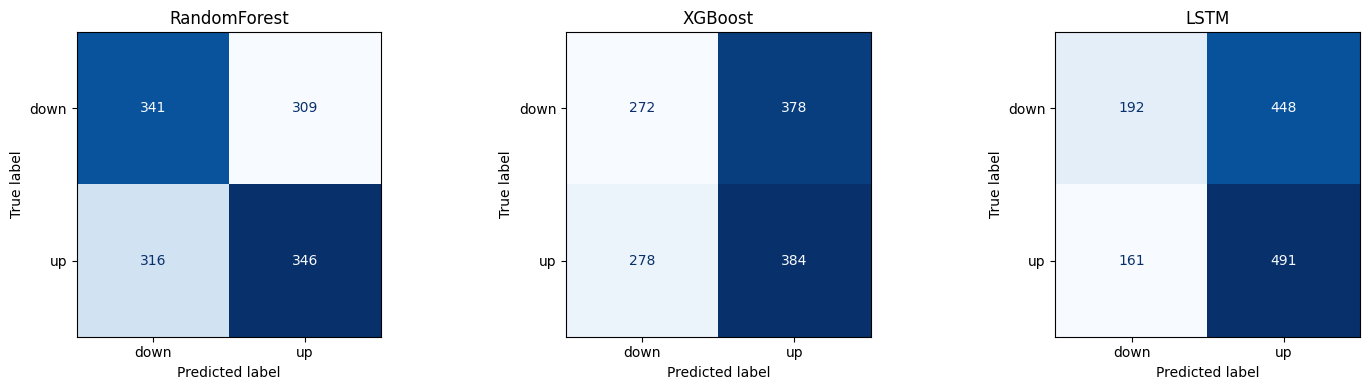

In [10]:
fig, axes = plt.subplots(1, len(pred), figsize=(5*len(pred), 4))
for ax, name in zip(np.atleast_1d(axes), pred):
    ConfusionMatrixDisplay(confusion_matrix(truth[name], pred[name]),
        display_labels=["down","up"]).plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name)
plt.tight_layout(); plt.show()

**Interpretation.** Confusion matrices conifrm the conclusions on the basis of prexious evaluation. They show that all three models perform close to random guessing on next-hour return direction, with accuracies of roughly 50%. This is consistent with the well-known difficulty of predicting short-horizon price direction. RandomForest is the most balanced classifier, distributing its predictions fairly evenly between the "down" and "up" classes (341/346 correct on the diagonal). XGBoost and LSTM, in contrast, exhibit a strong bias toward the "up" class: they label the majority of samples as "up", which yields high recall on true upward moves (e.g. 491 of 652 for LSTM) but poor performance on downward moves (only 192 correctly identified by LSTM, versus 448 misclassified as "up").

## 4. ROC and Precision-Recall curves

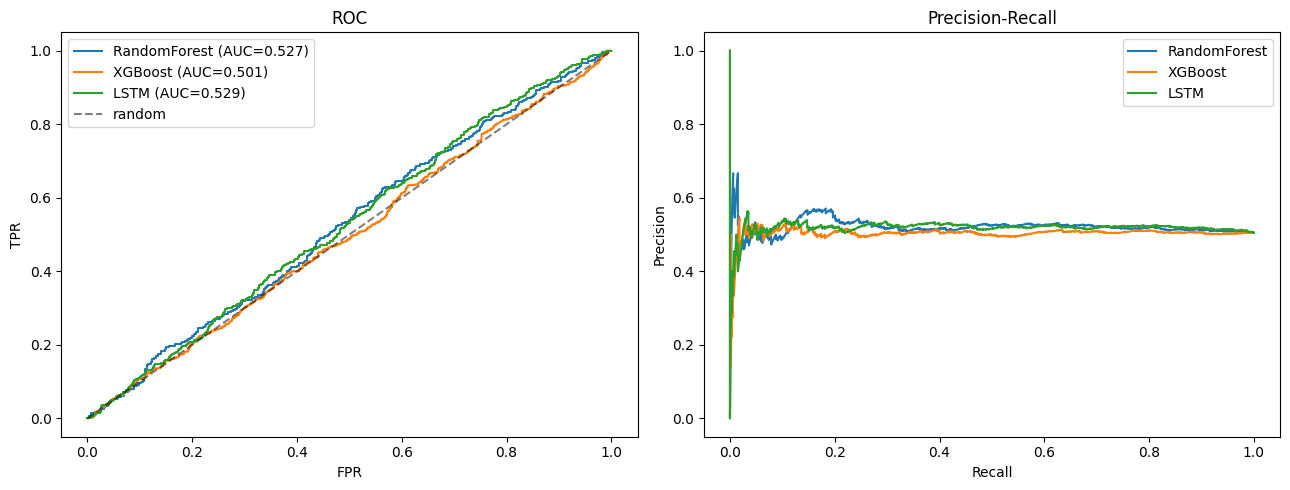

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for name in proba:
    fpr, tpr, _ = roc_curve(truth[name], proba[name])
    ax[0].plot(fpr, tpr, label=f"{name} (AUC={auc(fpr, tpr):.3f})")
ax[0].plot([0,1],[0,1],"k--",alpha=0.5,label="random")
ax[0].set_title("ROC"); ax[0].set_xlabel("FPR"); ax[0].set_ylabel("TPR"); ax[0].legend()
for name in proba:
    pr, rc, _ = precision_recall_curve(truth[name], proba[name])
    ax[1].plot(rc, pr, label=name)
ax[1].set_title("Precision-Recall"); ax[1].set_xlabel("Recall"); ax[1].set_ylabel("Precision"); ax[1].legend()
plt.tight_layout(); plt.show()

In [12]:
def auc_ci(y, p, n=2000, seed=42):
    """Bootstrap confidence interval for the ROC-AUC score.

    Resamples the observations with replacement ``n`` times and recomputes
    ROC-AUC on each resample, yielding an empirical 95% confidence interval.
    Resamples in which only one class is present are skipped, since ROC-AUC
    is undefined for a single class.

    Parameters
    ----------
    y : numpy.ndarray, shape (n_obs,)
        Ground-truth binary labels (0/1). Must support positional indexing,
        so pass a NumPy array rather than a pandas Series.
    p : numpy.ndarray, shape (n_obs,)
        Predicted probability of the positive class, aligned with ``y``.
    n : int, optional
        Number of bootstrap resamples (default 2000).
    seed : int, optional
        Seed for the random number generator, for reproducibility (default 42).

    Returns
    -------
    numpy.ndarray, shape (2,)
        The 2.5th and 97.5th percentiles of the bootstrap AUC distribution,
        i.e. the lower and upper bounds of the 95% confidence interval. An
        interval that contains 0.5 indicates the model is not statistically
        distinguishable from random guessing.
    """
    rng = np.random.default_rng(seed); n_obs = len(y); aucs = []
    for _ in range(n):
        idx = rng.integers(0, n_obs, n_obs)
        if len(np.unique(y[idx])) < 2: continue
        aucs.append(roc_auc_score(y[idx], p[idx]))
    return np.percentile(aucs, [2.5, 97.5])

for name in proba:
    y, p = truth[name], proba[name]
    point = roc_auc_score(y, p)
    lo, hi = auc_ci(y, p)
    flag = "-" if lo <= 0.5 <= hi else "above 0.5"
    print(f"{name:13s} AUC = {point:.3f}  95% CI [{lo:.3f}, {hi:.3f}]  {flag}")

RandomForest  AUC = 0.527  95% CI [0.497, 0.559]  -
XGBoost       AUC = 0.501  95% CI [0.468, 0.531]  -
LSTM          AUC = 0.529  95% CI [0.496, 0.561]  -


**Interpretation**: The ROC and Precision–Recall agree with all of the previous conclusions: none of the models shows meaningful predictive skill. All **ROC curves** lie almost on top of the diagonal "random" line, with AUC values of 0.527 (RandomForest), 0.501 (XGBoost) and 0.529 (LSTM), so they are essentially similar to the ransom choice. Bootstrap 95% confidence intervals for ROC-AUC (2,000 resamples) all include 0.50 — RandomForest [0.497, 0.559], XGBoost [0.468, 0.531], LSTM [0.496, 0.561] — so none of the models is statistically distinguishable from random guessing at the 5% level. This formally confirms the absence of a meaningful directional edge.


**The precision–recall curves** tell the same story. Across the full range of recall, precision stays flat at roughly 0.50, matching the base rate of the positive ("up") class. A useful classifier would show precision well above this base rate at low recall; the absence of any such lift indicates that the predicted probabilities carry little information about the true class.


## 5. Interpretability with SHAP

In [13]:
import shap
def shap_explain(model, X_sample, title):
    """Produce the three required SHAP views for a tree model.

    Shows a global importance bar plot, a beeswarm (impact + direction) and a
    waterfall for a single prediction. Binary classifiers whose SHAP values are
    returned as 3-D (samples, features, classes) are reduced to the positive class.

    Parameters
    ----------
    model : fitted tree model
        For example a RandomForest or XGBoost classifier.
    X_sample : pandas.DataFrame
        Rows to explain (a small slice keeps SHAP fast).
    title : str
        Title prefix printed above each plot.

    Returns
    -------
    shap.Explanation
        The (positive-class) explanation object.
    """
    explainer = shap.TreeExplainer(model)
    expl = explainer(X_sample)
    if hasattr(expl, "values") and expl.values.ndim == 3:    # (n, features, classes)
        expl = expl[:, :, 1]                                 # keep the "up" class
    print(f"--- {title}: global importance ---");   shap.plots.bar(expl, show=True)
    print(f"--- {title}: impact & direction ---");  shap.plots.beeswarm(expl, show=True)
    print(f"--- {title}: single prediction ---");   shap.plots.waterfall(expl[0], show=True)
    return expl
X_shap = X_test.iloc[:300]      # a manageable slice keeps SHAP fast

--- Random Forest: global importance ---


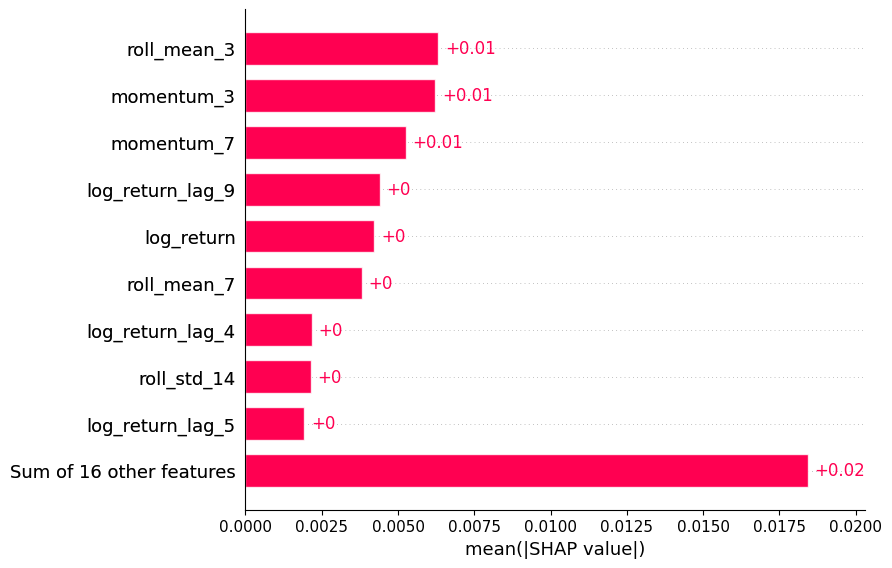

--- Random Forest: impact & direction ---


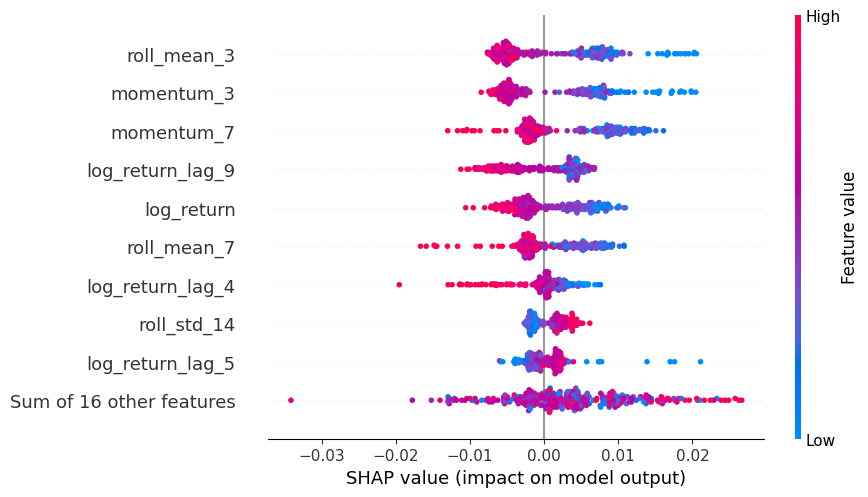

--- Random Forest: single prediction ---


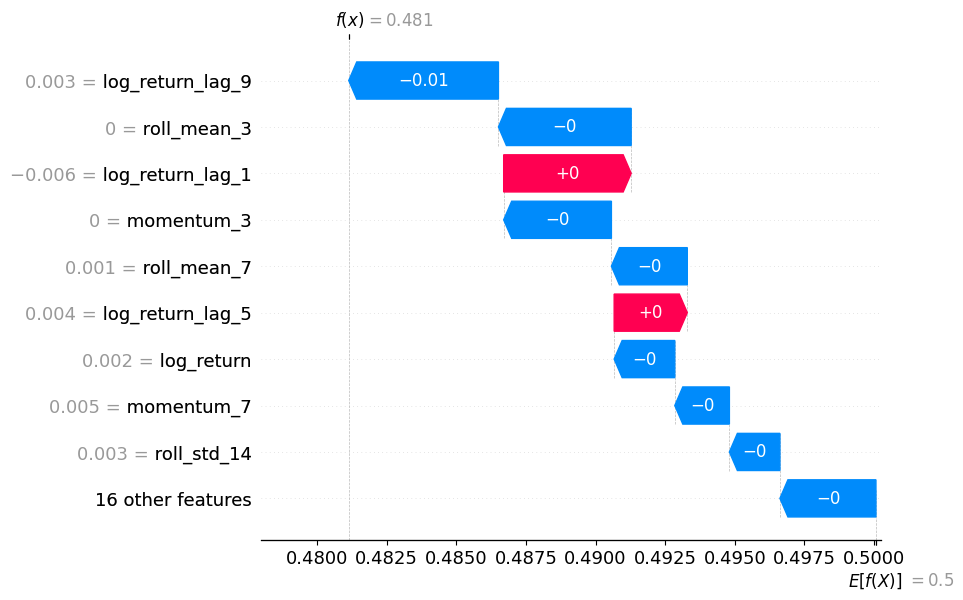

In [14]:
_ = shap_explain(rf_model, X_shap, 'Random Forest')

**Interpretation (Random Forest).** **The mean absolute SHAP plot** ranks features by their average contribution to the output. Short-window momentum and moving-average features dominate: roll_mean_3, momentum_3 and momentum_7 are the most influential - followed by several lagged log-return features. However, the absolute magnitudes are very small (mean |SHAP| ≈ 0.006–0.018 at most), confirming that no single feature exerts a strong pull on the predicted probability.

**The beeswarm summary** shows the direction of these effects. For the top features the relationship is fairly monotonic: high feature values (red) tend to push the prediction toward the "up" class (positive SHAP), while low values (blue) push toward "down". The effect is consistent but weak, and the SHAP distributions are narrow and centred near zero, reinforcing that individual features carry only marginal signal.

**The waterfall plot** decomposes one individual prediction. Starting from the base value E[f(X)] = 0.500, the cumulative feature contributions move the output only slightly, to f(x) = 0.481. Almost every feature contributes a near-zero effect; the largest single push (log_return_lag_9, −0.01) is what nudges this sample marginally toward the "down" class. The tiny total deviation from the 0.5 baseline is characteristic of a model with little discriminative power.

Overall, the SHAP analysis is consistent with the ROC/PR results: the features behave sensibly and in economically plausible directions (recent momentum matters most), but their predictive contribution is too small to translate into a reliably profitable signal at this horizon.

--- XGBoost: global importance ---


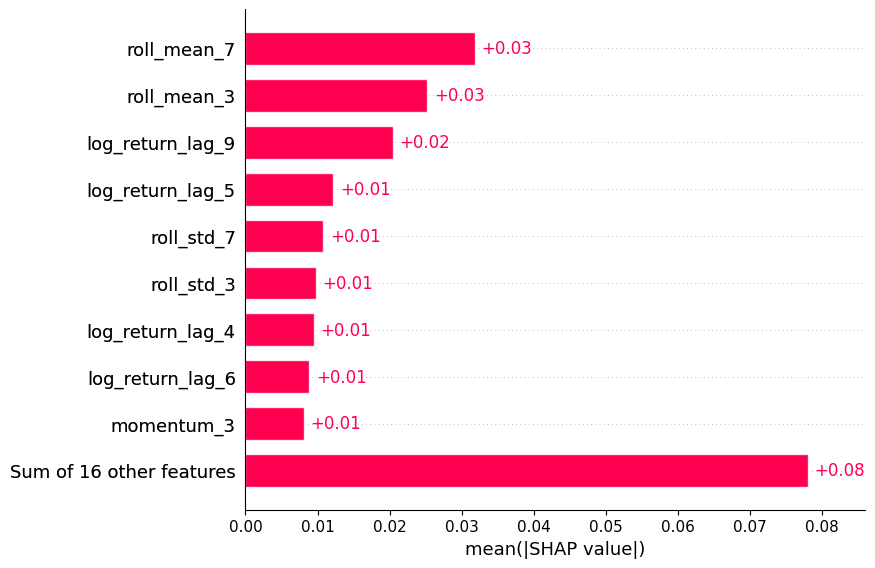

--- XGBoost: impact & direction ---


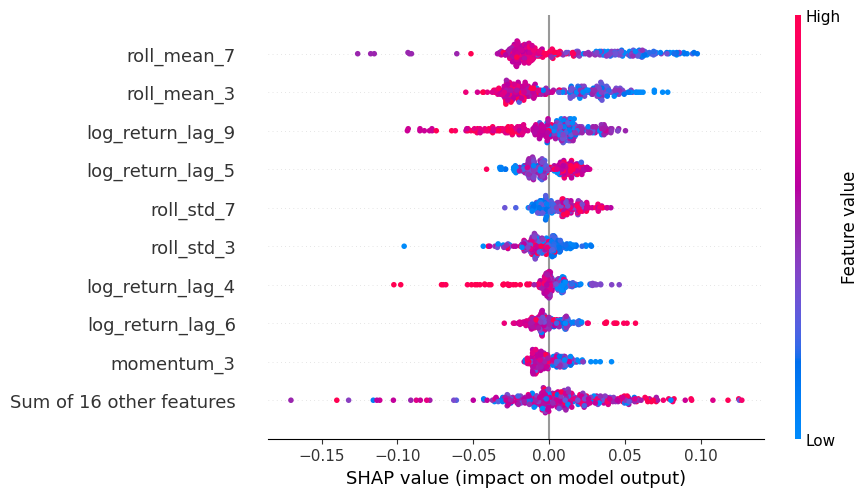

--- XGBoost: single prediction ---


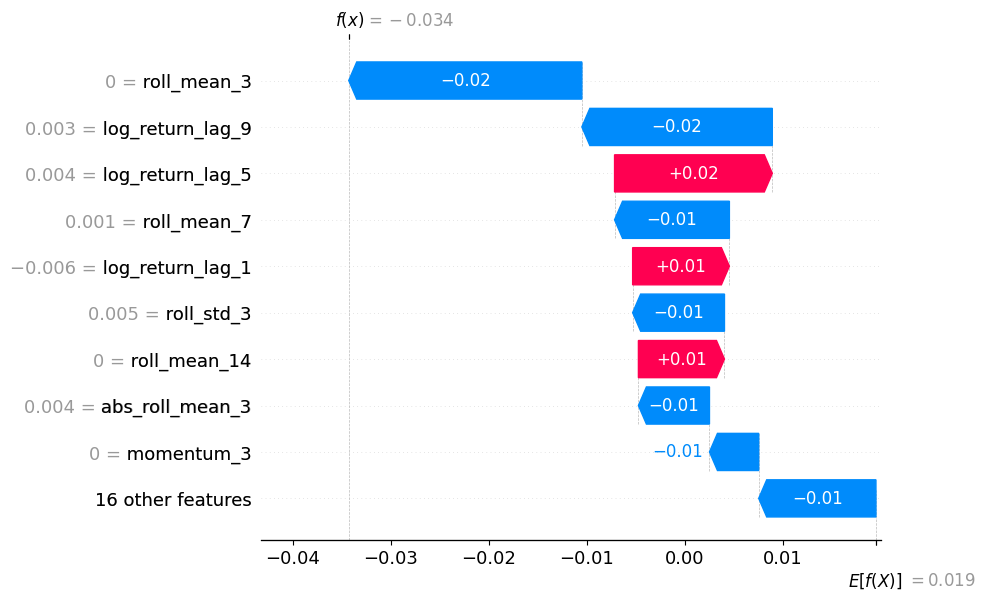

In [15]:
_ = shap_explain(xgb_model, X_shap, 'XGBoost')

**Interpretation (XGBoost).** **The mean absolute SHAP plot** SHAP analysis of the XGBoost model identifies short-window moving averages (roll_mean_7, roll_mean_3) and the longer log-return lag (log_return_lag_9) as the most influential features, followed by volatility measures (roll_std_7, roll_std_3) and several additional return lags. Importance is fairly diffuse rather than concentrated: the "Sum of 16 other features" bar (≈ 0.08) is the single largest contributor, indicating that predictive weight is spread across many features.

**The beeswarm plot** shows broadly monotonic effects for the leading features - high values of roll_mean_7 and roll_mean_3 (red) tend to push the prediction toward the "up" class - but the SHAP distributions are wide and heavily overlapping around zero, with substantial two-sided spread. This signals unstable, context-dependent feature effects rather than a clean directional signal.

**The waterfall plot** decomposes one prediction: from the base value E[f(X)] = 0.019, contributions are small and partly offsetting (e.g. roll_mean_3 −0.02 against log_return_lag_5 +0.02), moving the output to f(x) = −0.034. No single feature decisively drives the result.

Overall, the SHAP analysis shows the model drawing on economically plausible features (recent moving averages, momentum, volatility), but the wide, near-symmetric effect distributions are consistent with the model's near-chance discriminative power (AUC = 0.501).

(500, 20, 8)


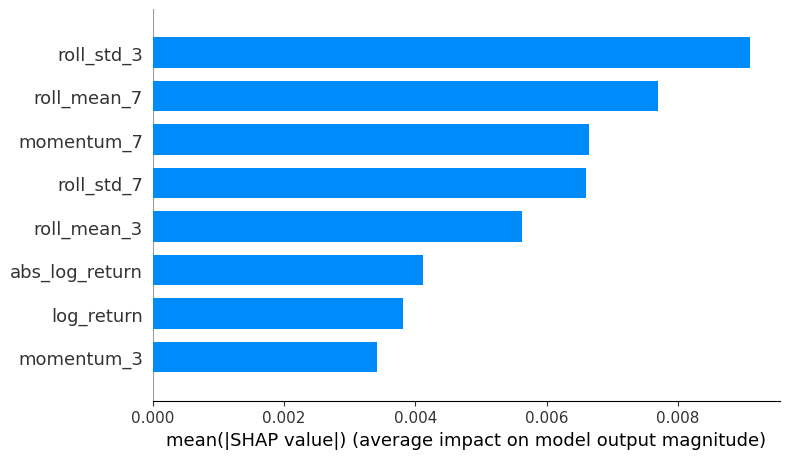

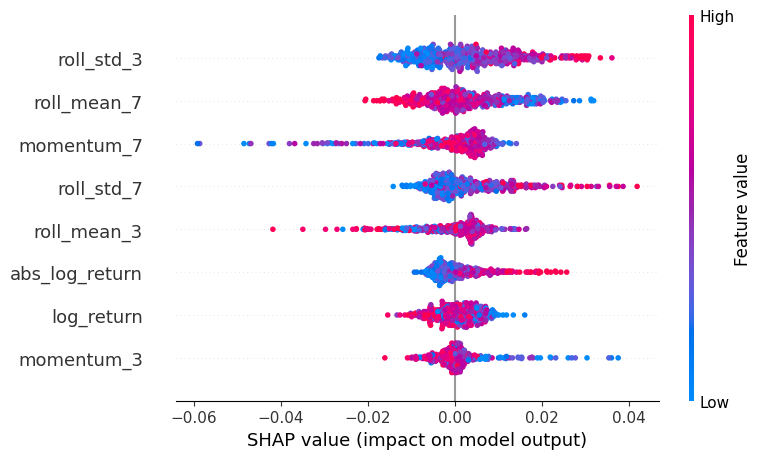

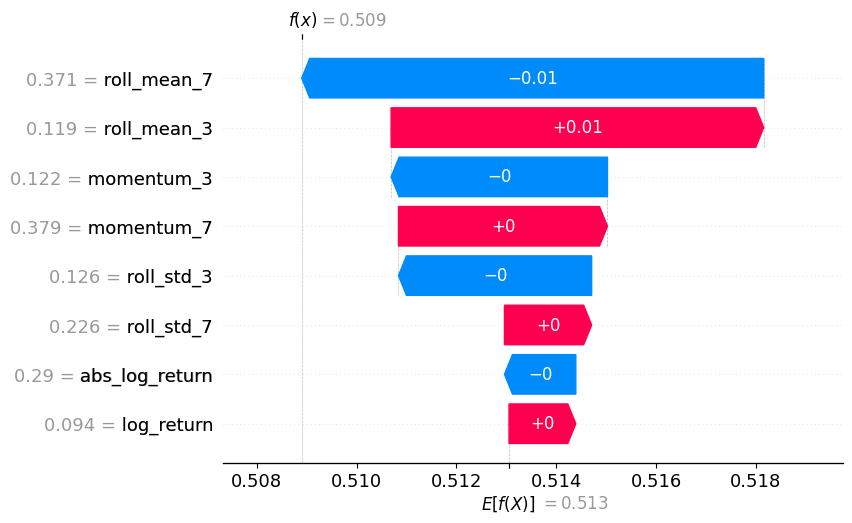

In [16]:
rng = np.random.default_rng(0)
bg = X_train_seq[rng.choice(len(X_train_seq), size=100, replace=False)]
explainer = shap.GradientExplainer(lstm_model, bg)
X_eval = X_test_seq[:500]
shap_values = explainer.shap_values(X_eval)
sv = shap_values[0] if isinstance(shap_values, list) else shap_values
sv = np.asarray(sv)
if sv.ndim == 4:        
    sv = sv[..., 0]
print(sv.shape)   
sv_agg = sv.sum(axis=1)              
x_agg  = X_eval.mean(axis=1)         

# bar (mean |SHAP|)
shap.summary_plot(sv_agg, x_agg, feature_names=LSTM_FEATURES, plot_type="bar")

# beeswarm
shap.summary_plot(sv_agg, x_agg, feature_names=LSTM_FEATURES)    
base_value = float(lstm_model.predict(bg, verbose=0).mean())

i = 0  

expl = shap.Explanation(
    values       = sv_agg[i],         
    base_values  = base_value,
    data         = x_agg[i],         
    feature_names= LSTM_FEATURES,
)
shap.plots.waterfall(expl) 

**Interpretation.** **The mean absolute SHAP plot** ranks short-window volatility (roll_std_3) as the single most important feature, followed by moving averages (roll_mean_7, roll_mean_3) and momentum (momentum_7). Compared with XGBoost, the LSTM places relatively more weight on volatility features, but the overall magnitudes are small (mean |SHAP| ≈ 0.003–0.009), confirming that no feature exerts a strong influence on the output.

**The beeswarm plot** shows wide distributions centred on zero with heavily mixed colours: for most features, high and low values (red and blue) appear on both sides of the zero line, so the direction of each feature's effect is inconsistent across samples. A few features (momentum_7, roll_mean_3) display long one-sided tails, indicating a handful of samples where the feature had an unusually strong negative effect, but the bulk of the mass sits near zero. This is the signature of a model with weak, context-dependent feature effects rather than a stable directional signal.

**The waterfall plot** is the clearest illustration of this. Starting from the base value E[f(X)] = 0.513, the individual contributions almost perfectly cancel out - roll_mean_7 (−0.01) is offset by roll_mean_3 (+0.01), and the remaining features contribute essentially zero - so the final prediction f(x) = 0.513 lands exactly on the base rate. In other words, for this sample the model effectively defaults to the average "up" probability and extracts no net information from the features.

Overall, the LSTM's SHAP profile reinforces the earlier finding: the model draws on economically reasonable features (volatility, moving averages, momentum), but their contributions are small - fully consistent with its near-chance AUC of 0.529.

## 6. Uncertainty — MC-Dropout on the LSTM

In [17]:
N_ITER = 100
def mc_dropout_predict(model, X, n_iter=N_ITER):
    """Estimate predictive mean and uncertainty via Monte-Carlo Dropout.

    Runs ``n_iter`` stochastic forward passes with dropout kept active, turning
    the network into an approximate Bayesian model.

    Parameters
    ----------
    model : tf.keras.Model
        A model containing Dropout layers.
    X : numpy.ndarray
        Input sequences.
    n_iter : int, optional
        Number of stochastic forward passes.

    Returns
    -------
    tuple of numpy.ndarray
        Per-sample mean probability and standard deviation (uncertainty).
    """
    s = np.stack([model(X, training=True).numpy().ravel() for _ in range(n_iter)])
    return s.mean(0), s.std(0)
mc_mean, mc_std = mc_dropout_predict(lstm_model, X_test_seq)
mc_pred = (mc_mean > 0.5).astype(int)
print(f"Accuracy {accuracy_score(y_test_seq, mc_pred):.4f} | "
      f"ROC-AUC {roc_auc_score(y_test_seq, mc_mean):.4f} | "
      f"mean uncertainty {mc_std.mean():.4f}")

Accuracy 0.5232 | ROC-AUC 0.5275 | mean uncertainty 0.0192


In [18]:
from tensorflow.keras.layers import BatchNormalization, Dropout
has_bn = any(isinstance(l, BatchNormalization) for l in lstm_model.layers)
print("BatchNorm:", has_bn)   # False

BatchNorm: False


ECE: 0.0081 (closer to 0 = better)


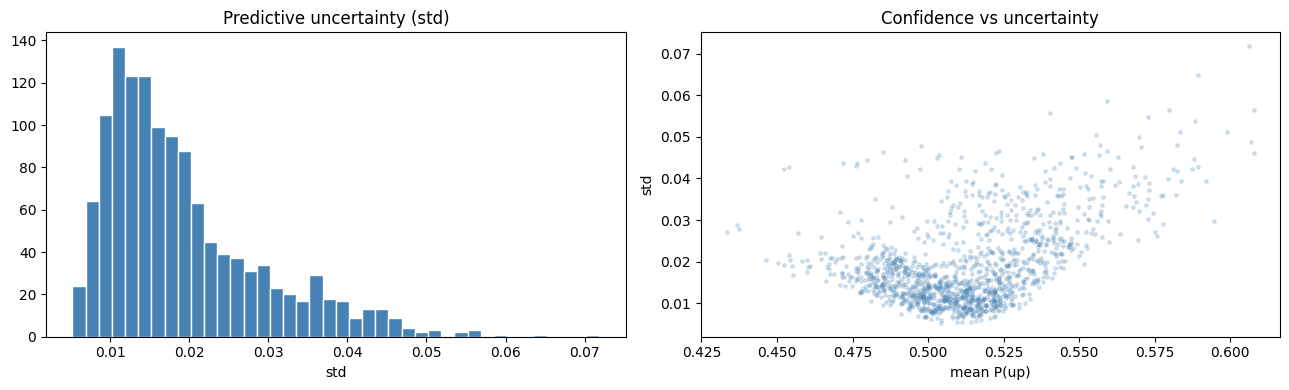

In [19]:
def expected_calibration_error(y_true, y_prob, n_bins=10):
    """Compute the Expected Calibration Error (ECE).

    Bins predictions by confidence and averages the gap between confidence and
    empirical accuracy in each bin (0 = perfectly calibrated).

    Parameters
    ----------
    y_true : numpy.ndarray
        Ground-truth 0/1 labels.
    y_prob : numpy.ndarray
        Predicted probability of the positive class.
    n_bins : int, optional
        Number of equal-width probability bins.

    Returns
    -------
    float
        The ECE value.
    """
    bins = np.linspace(0, 1, n_bins + 1); ece = 0.0
    for i in range(n_bins):
        m = (y_prob >= bins[i]) & (y_prob < bins[i+1])
        if m.sum() == 0: continue
        ece += m.sum() * abs(y_true[m].mean() - y_prob[m].mean())
    return ece / len(y_true)
print(f"ECE: {expected_calibration_error(y_test_seq, mc_mean):.4f} (closer to 0 = better)")
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].hist(mc_std, bins=40, color="steelblue", edgecolor="white")
ax[0].set_title("Predictive uncertainty (std)"); ax[0].set_xlabel("std")
ax[1].scatter(mc_mean, mc_std, s=6, alpha=0.2, color="steelblue")
ax[1].set_title("Confidence vs uncertainty"); ax[1].set_xlabel("mean P(up)"); ax[1].set_ylabel("std")
plt.tight_layout(); plt.show()

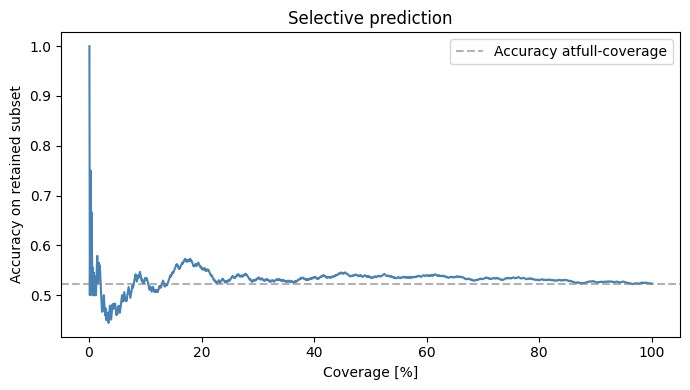

In [20]:
order = np.argsort(mc_std)                                 
correct = (mc_pred[order] == y_test_seq[order]).astype(float)
coverage = np.arange(1, len(correct)+1) / len(correct)
selective_acc = np.cumsum(correct) / np.arange(1, len(correct)+1)

plt.figure(figsize=(7,4))
plt.plot(coverage*100, selective_acc, color="steelblue")
plt.axhline(accuracy_score(y_test_seq, mc_pred), color="gray", ls="--", alpha=.6,
            label="Accuracy atfull-coverage")
plt.xlabel("Coverage [%]")
plt.ylabel("Accuracy on retained subset")
plt.title("Selective prediction"); plt.legend(); plt.tight_layout(); plt.show()

**Interpretation.** The MC-Dropout LSTM is **well-calibrated**: ECE ≈ 0.0081, so its stated confidence closely matches its empirical accuracy, and the mean predictive uncertainty (std ≈ 0.019) is small and stable. But calibration is not the same as usefulness - the model is calibrated around ~0.51 accuracy, so it reliably reports that it is unsure. Because the uncertainty is uniformly low rather than concentrated on a confidently-correct subset, restricting to the lowest-uncertainty predictions would offer little headroom here: there is simply little signal to be confident about.Sorting predictions by MC-Dropout confidence and expanding coverage leaves accuracy flat at the ~0.52 base rate, confirming that the uncertainty estimate carries no actionable information for selecting more reliable predictions.

## 7. Backtest — PPO and a model-signal strategy

In [21]:
def backtest_metrics(strategy_returns, name):
    """Summarise a trading strategy from its per-step log-returns.

    Parameters
    ----------
    strategy_returns : array-like
        Per-hour log-returns realised by the strategy (0 when flat).
    name : str
        Strategy label.

    Returns
    -------
    tuple of (numpy.ndarray, dict)
        The equity curve and a metrics dict (total return %, annualised Sharpe,
        max drawdown %, win rate %).
    """
    r = np.asarray(strategy_returns, dtype=float)
    equity = np.cumprod(np.exp(r))
    sharpe = (r.mean() / (r.std() + 1e-9)) * np.sqrt(24 * 365)
    peak = np.maximum.accumulate(equity); max_dd = ((equity - peak) / peak).min() * 100
    win = (r[r != 0] > 0).mean() * 100 if (r != 0).any() else 0.0
    return equity, {"Strategy": name, "Total return %": (equity[-1]-1)*100,
                    "Sharpe": sharpe, "Max drawdown %": max_dd, "Win rate %": win}
bh_equity, bh_m = backtest_metrics(test_fwd, "Buy & Hold")    # always long

In [22]:
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
class TradingEnv(gym.Env):
    """Single-asset long/flat trading environment (mirrors notebook 03).

    Observation: scaled feature vector. Action: 0 = flat, 1 = long. Reward:
    next-hour log-return when long, small penalty when flat.
    """
    metadata = {"render_modes": []}
    def __init__(self, obs, ret, flat_penalty=1e-4):
        super().__init__(); self.obs = obs.astype(np.float32); self.ret = ret.astype(np.float32)
        self.flat_penalty = flat_penalty; self.action_space = spaces.Discrete(2)
        self.observation_space = spaces.Box(-np.inf, np.inf, (obs.shape[1],), np.float32); self.t = 0
    def reset(self, seed=None, options=None):
        super().reset(seed=seed); self.t = 0; return self.obs[self.t], {}
    def step(self, a):
        r = float(self.ret[self.t]) if a == 1 else -self.flat_penalty
        self.t += 1; return self.obs[self.t], r, self.t >= len(self.obs)-1, False, {}
ppo_model = PPO.load(MODELS_DIR / "ppo_agent.zip")
env = TradingEnv(test_scaled, test_fwd); obs, _ = env.reset(); done = False
ppo_actions, ppo_returns = [], []
while not done:
    a, _ = ppo_model.predict(obs, deterministic=True)
    obs, _, done, _, _ = env.step(a)
    ppo_actions.append(int(a)); ppo_returns.append(test_fwd[env.t-1] if a == 1 else 0.0)
ppo_equity, ppo_m = backtest_metrics(ppo_returns, "PPO agent")
print(f"PPO time in market: {np.mean(ppo_actions)*100:.1f}%")

PPO time in market: 57.9%


                Total return %  Sharpe  Max drawdown %  Win rate %
Strategy                                                          
Buy & Hold             -14.188  -2.138         -23.004      50.650
PPO agent              -16.506  -3.103         -21.757      51.720
XGBoost signal         -22.176  -4.220         -30.018      50.526


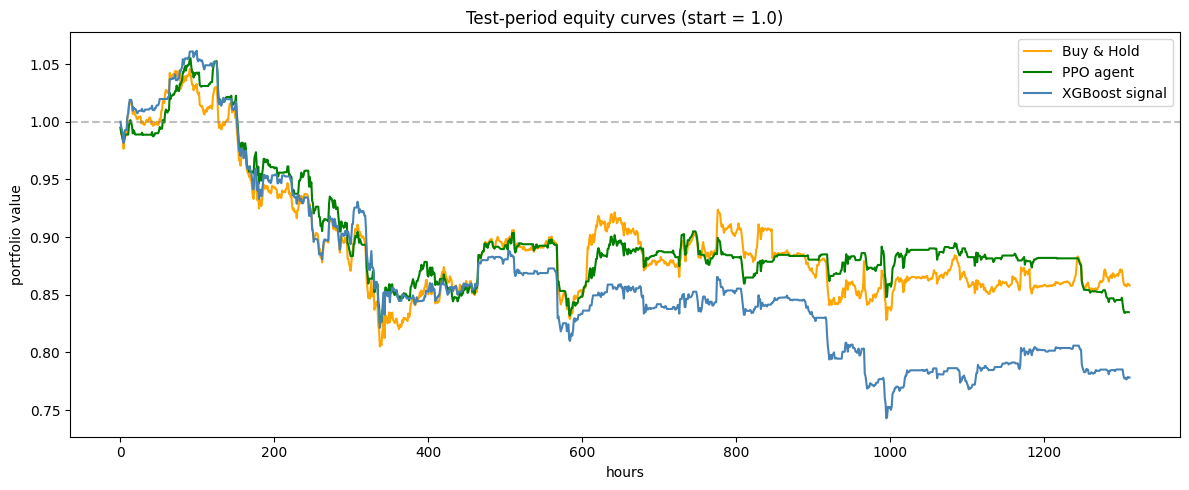

,Total return %,Sharpe,Max drawdown %,Win rate %
Strategy,,,,
Buy & Hold,-14.188,-2.138,-23.004,50.650
PPO agent,-16.506,-3.103,-21.757,51.720
XGBoost signal,-22.176,-4.220,-30.018,50.526


In [23]:
xgb_signal = (proba["XGBoost"] > 0.5).astype(int)            # 1 long, 0 flat
xgb_equity, xgb_m = backtest_metrics(xgb_signal * test_fwd, "XGBoost signal")
bt_table = pd.DataFrame([bh_m, ppo_m, xgb_m]).set_index("Strategy").round(3)
print(bt_table)
plt.figure(figsize=(12, 5))
plt.plot(bh_equity,  label="Buy & Hold", color="orange")
plt.plot(ppo_equity, label="PPO agent",  color="green")
plt.plot(xgb_equity, label="XGBoost signal", color="steelblue")
plt.axhline(1.0, color="gray", linestyle="--", alpha=0.5)
plt.title("Test-period equity curves (start = 1.0)")
plt.xlabel("hours"); plt.ylabel("portfolio value"); plt.legend(); plt.tight_layout(); plt.show()
bt_table

**Interpretation.** No strategy makes money - but the test window (the final ~15% of 2025) was itself a **downtrend**, so even Buy & Hold lost 14.19% (Sharpe -2.14). Against that benchmark: the **PPO agent did worse** (-17.9%, Sharpe -3.44) despite being in the market only 58% of the time; the **XGBoost-signal strategy was worst** (-22.18%). Every Sharpe is negative, so **none beats Buy & Hold on a genuine risk-adjusted basis**. 

## 8. Export headline results for the report

In [24]:
metrics_table.round(4).to_csv(REPORTS_DIR / "metrics_table.csv")
bt_table.to_csv(REPORTS_DIR / "backtest_table.csv")
print("Saved metrics_table.csv and backtest_table.csv to", REPORTS_DIR)

Saved metrics_table.csv and backtest_table.csv to c:\Users\Użytkownik\Desktop\studia\magisterka\Machine learning\Project\MLDA - checking\reports


## 9. Conclusions & business insights

**Headline.** No model found a reliable directional edge. Random Forest was best (0.527 ROC-AUC) but beat the stratified baseline (0.519) by less than 0.01; XGBoost and the LSTM were essentially at chance. In the backtest, every strategy lost money over the downtrending test window and every Sharpe was negative, so **none beat Buy & Hold on a risk-adjusted basis**.

**What SHAP showed.** The models lean on short-horizon return/momentum and recent-volatility features, in a mean-reverting direction, but with small magnitudes - importance is spread thinly because there is little signal to concentrate on.

**When to trust the model.** The MC-Dropout LSTM is well-calibrated (ECE ≈ 0.0081): it honestly reports low confidence, which is appropriate given ~0.51 accuracy. Calibration is good; discriminative power is not.

**Limitations.** A single asset and a single year (2025); a test window that happened to be a downtrend, which flatters defensive strategies; transaction costs, slippage and latency are not modelled; hourly granularity that discards intra-hour information.

**Future work.** Add multiple assets and cross-asset features; incorporate order-book / on-chain signals that may carry more information than price alone; use walk-forward retraining to track regime shifts; replace binary long/flat with continuous position sizing; and give the RL agent a cost-aware reward so policies are evaluated under realistic frictions.

-> **Next:** `05_final_report.ipynb`.